In [63]:
from astropy.io import fits
from astropy.wcs import WCS

In [64]:
import numpy as np

In [65]:
# file = fits.open("../images/src_00002.fits") # Header Data Unit

In [67]:
file = fits.open("../src/cutouts/src_00021.fits") # Header Data Unit

In [68]:
file.info()

Filename: ../src/cutouts/src_00021.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      17   ()      
  1  SCI           1 ImageHDU        39   (32, 32)   float32   
  2  ERR           1 ImageHDU        39   (32, 32)   float32   
  3  SEGMAP        1 ImageHDU        39   (32, 32)   int32   
  4  MASK          1 ImageHDU        39   (32, 32)   uint8   


In [69]:
type(file)

astropy.io.fits.hdu.hdulist.HDUList

In [70]:
# SCI_BKSUB (1) — the background-subtracted science image. This is a CEERS-specific addition (standard JWST i2d files don't have it), and it's the extension you want to feed to photutils detection, since the background is already removed. 11500 × 6500 pixels, float64.

In [71]:
# SCI (2) — the science mosaic without background subtraction, in MJy/sr. Its header contains the WCS keywords you'll need to convert pixel coordinates to RA/Dec.

In [72]:
# ERR (3) — total 1σ uncertainty per pixel. This is what statmorph wants as its weightmap argument, and what you can pass to detect_sources logic for S/N thresholding.

In [73]:
sci = file[1].data 
err = file["ERR"].data
wcs = WCS(file["SCI"].header)
# wht = file["WHT"].data

Set OBSGEO-B to     9.050679 from OBSGEO-[XYZ].
Set OBSGEO-H to 1677452214.324 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [74]:
print(sci)

[[-1.1817832e-03 -5.9365510e-04 -3.0779617e-04 ...  7.2738074e-04
   3.4852431e-03  4.0886463e-03]
 [-2.1185696e-03 -5.0706295e-03 -4.1629290e-03 ...  2.4180911e-03
   4.4122119e-03  4.8042512e-03]
 [ 1.4102019e-03 -9.6350873e-04 -3.1612334e-03 ...  1.7516236e-03
   7.6008914e-04  2.1095916e-03]
 ...
 [-2.8612858e-03 -1.2697058e-04  3.4866405e-03 ...  7.0281292e-04
   5.4624602e-03  1.1652960e-03]
 [ 9.1136131e-04  1.6588104e-04  9.6244097e-05 ...  3.5714942e-03
   2.9094359e-03 -2.4635205e-03]
 [ 5.2500875e-03  3.8707652e-03 -5.2513665e-04 ...  1.9998343e-03
   2.0636837e-03 -2.5262509e-03]]


In [75]:
print(err)

[[0.01176406 0.0116367  0.01151702 ... 0.00959648 0.01016458 0.01074466]
 [0.0117702  0.01167097 0.01162773 ... 0.00980349 0.00995215 0.01018814]
 [0.01010853 0.01008349 0.00974974 ... 0.00992867 0.00989134 0.0098121 ]
 ...
 [0.00947949 0.00930437 0.00955435 ... 0.0115952  0.01132403 0.01153699]
 [0.00952289 0.00913897 0.00920791 ... 0.01161409 0.01146073 0.01175051]
 [0.00954659 0.00911412 0.00913316 ... 0.01031468 0.01023283 0.01049356]]


In [76]:
print(wcs)

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 214.825 52.825
CRPIX : 16245.5 532.5
PC1_1 PC1_2  : -0.64678977951046 -0.76266832969569
PC2_1 PC2_2  : -0.76266832969569 0.64678977951046
CDELT : 8.3333333333333e-06 8.3333333333333e-06
NAXIS : 32  32


In [77]:
# good = wht > 0

In [78]:

# print(f"Total pixels: {sci.size}")
# print(f"Pixels with coverage: {good.sum()} ({100*good.sum()/sci.size:.1f}%)")
# print(f"SCI stats in covered region: min={sci[good].min():.4f}, "
#       f"max={sci[good].max():.4f}, mean={sci[good].mean():.4f}")
# print(f"NaNs in ERR within covered region: {np.isnan(err[good]).sum()}")

In [79]:
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval

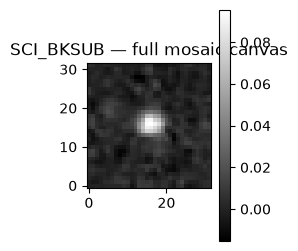

In [80]:
plt.figure(figsize=(2,3))
plt.imshow(sci, origin="lower", cmap="gray")
plt.title("SCI_BKSUB — full mosaic canvas")
plt.colorbar()
plt.show()

In [81]:
type(sci)

numpy.ndarray

In [82]:
sci.shape

(32, 32)